In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# data cleaning
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

Exercise: create the following plots, horizontal bar charts:

- Top 10 highest paid skills for Data Analysts
- Top 10 most in-demand skills for Data Analysts

In [138]:
# filter for data analysts only and select the necessary columns
df_da = df.loc[
    (df["job_title_short"] == "Data Analyst") & (df["salary_year_avg"].notna()),
    ["job_title_short", "job_skills", "salary_year_avg"]
].copy()

In [139]:
# explode the dataframe
explode_df = df_da.explode("job_skills").reset_index(drop=True)
dataframes = []

### Calculate Top Paying Skills

In [140]:
# creating aggregations
top_paying_skills = explode_df.groupby("job_skills").agg(
    median_yearly_salary=("salary_year_avg", "median")
).sort_values(by="median_yearly_salary", ascending=False).head(11)

# remove outlier
top_paying_skills = top_paying_skills.iloc[1:].reset_index()
top_paying_skills_final = top_paying_skills.sort_values(by="median_yearly_salary")
dataframes.append(top_paying_skills_final)
top_paying_skills_final

,job_skills,median_yearly_salary
9,twilio,138500.0
8,vmware,147500.0
7,mxnet,149000.0
6,golang,155000.0
5,datarobot,155485.5
4,couchbase,160515.0
2,terraform,163782.0
3,gitlab,163782.0
1,dplyr,167500.0
0,solidity,179000.0


### Calculate Most In Demand Skills

In [141]:
# filter most request skills
most_in_demand_skills = explode_df["job_skills"].value_counts().head(10).reset_index()
median_salaries = []

# get the median yearly salary for each top skill
for skill in most_in_demand_skills["job_skills"]:
    median_salaries.append((explode_df.loc[explode_df["job_skills"] == skill,"salary_year_avg"].median()))

# add the salaries to each respective skill on the dataframe
most_in_demand_skills["median_yearly_salary"] = median_salaries
most_in_demand_skills = most_in_demand_skills.sort_values(by="median_yearly_salary", ascending=False)
most_in_demand_skills_final = most_in_demand_skills.sort_values(by="median_yearly_salary")
dataframes.append(most_in_demand_skills_final)
most_in_demand_skills_final

,job_skills,count,median_yearly_salary
7,word,523,80000.0
1,excel,2135,84479.0
8,powerpoint,518,85000.0
5,power bi,1042,90000.0
6,sas,1006,90000.0
9,sql server,336,92150.0
0,sql,3079,92500.0
4,r,1073,92527.5
3,tableau,1657,95000.0
2,python,1838,98500.0


### Create Plots

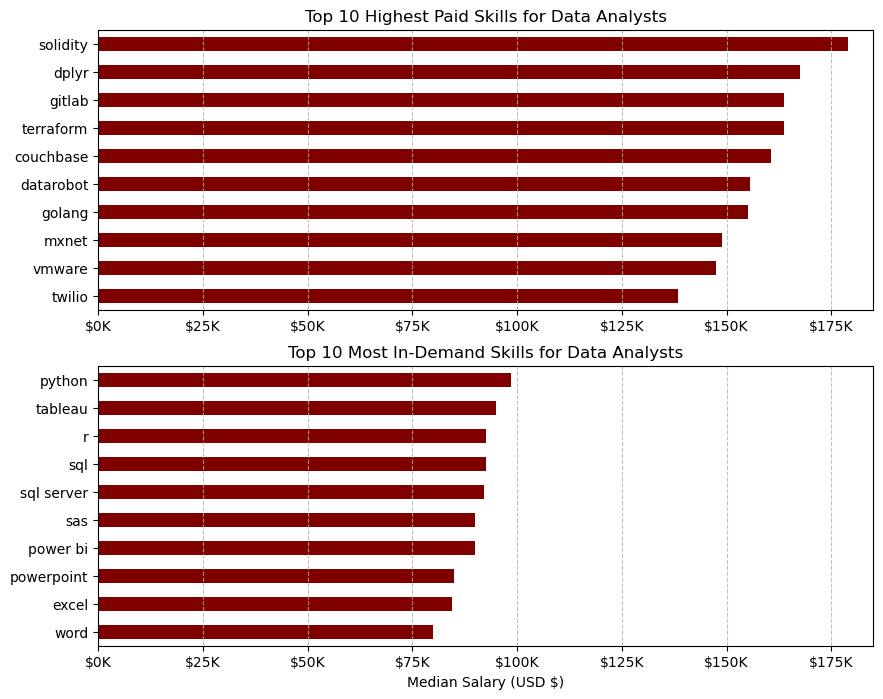

In [143]:
# create subplots
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))

# add the data to each plot
for i, df in enumerate(dataframes):
    df.plot(
        kind="barh",
        ax=ax[i], 
        x="job_skills", 
        y="median_yearly_salary", 
        legend=False,
        color="maroon"
    )
    ax[i].set_xlim(0, 185_000)
    ax[i].grid(True, alpha=0.8, linestyle="--")
    ax[i].grid(False, axis="y")
    ax[i].set_ylabel("")
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))


# format plot 1
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")

# format plot 2
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_xlabel("Median Salary (USD $)")

plt.show()